# 14: End-to-End Observational Case Study

This lesson is a compact capstone for the DoWhy tutorial series. This lesson walks through a full observational causal workflow from a raw-looking table to a report-ready causal summary.

The case study asks:

> What is the total effect of proactive guidance on future engagement?

The data are synthetic so we can compare estimates to the known truth, but the workflow is written the way an applied analysis should be structured:

- define the business or policy question before modeling;
- document variables, timing, and graph assumptions;
- inspect confounding, overlap, and missingness;
- identify the estimand with DoWhy;
- compare estimators;
- run refutation and negative-control checks;
- avoid bad controls;
- summarize the result with limitations and recommended next steps.


## Learning Goals

By the end, you should be able to:

- Turn a realistic observational table into a causal analysis-ready dataset.
- Write a causal question as treatment, outcome, population, estimand, and time horizon.
- Build a graph that separates pre-treatment covariates, treatment, post-treatment mediators, and outcomes.
- Use DoWhy to identify and estimate an average total effect.
- Compare regression and propensity-based estimators.
- Diagnose propensity overlap, covariate balance, and bad-control mistakes.
- Run DoWhy refuters and negative-control checks.
- Produce a concise final causal report that does not overstate the evidence.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use mostly simulated or semi-synthetic observational datasets to study **End-To-End Observational Case Study**. DoWhy is mainly about causal modeling discipline: graph, estimand, estimator, and refuter. A controlled dataset lets us show how a change in assumptions changes the estimand and the credibility of the estimate.

Read each row as an observed unit in a business or policy system. The treatment, outcome, common causes, instruments, mediators, and anomaly indicators are named to mirror applied causal workflows and keep the examples close to realistic analysis language. The experiment is closer to a complete applied analysis. Question framing, design, estimation, diagnostics, and reporting are meant to be read together.

The simulation is designed to make the identifying assumptions and diagnostic checks visible. It is meant to expose the assumptions that would be hidden in real data, where the true counterfactual outcome is unavailable.


## Mathematical Foundation

<!-- math-foundation-note -->

DoWhy separates a causal workflow into estimand, identification, estimation, and refutation. The central estimand in many tutorials is

$$
\tau=\mathbb{E}\{Y(1)-Y(0)\}.
$$

Identification turns that counterfactual object into an observed-data expression. Estimation computes it from data. Refutation checks whether the conclusion is stable under changes that should not create a causal effect.





## Tutorial Workflow

### Case Study Brief

Imagine an organization has launched **proactive guidance**: a targeted intervention that offers extra help, education, or nudges to users who may benefit from it. The observed data are not randomized. Users with higher need or friction are more likely to receive guidance, and those same factors also affect later engagement.

The target estimand is the **average total effect** of proactive guidance on future engagement. Total effect means we allow downstream activation depth to change naturally after guidance. We do **not** adjust for activation depth when estimating the total effect, because activation depth is a post-treatment mediator.


#### Setup

The code below imports the libraries, creates output folders, and suppresses non-actionable warnings that would otherwise make the executed tutorial noisy. Code remains visible throughout the lesson.


In [ ]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings
# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="pydot.dot_parser")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
# Compatibility shim for DoWhy estimators written against older pandas Series integer indexing.
if not getattr(pd.Series, "_dowhy_integer_position_patch", False):
    _original_series_getitem = pd.Series.__getitem__
    def _dowhy_series_getitem_compat(self, key):
        try:
            return _original_series_getitem(self, key)
        except KeyError:
            if isinstance(key, int) and key not in self.index:
                return self.iloc[key]
            raise
    pd.Series.__getitem__ = _dowhy_series_getitem_compat
    pd.Series._dowhy_integer_position_patch = True
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
# Compatibility shim for DoWhy versions that expect the older NetworkX d_separated API.
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator
import statsmodels.api as sm
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from dowhy import CausalModel
import dowhy
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"DoWhy version: {getattr(dowhy, '__version__', 'unknown')}")


The lesson is ready once the DoWhy version and output folders print. Every saved output uses a `14_` prefix so the capstone outputs are easy to find.


### End-to-End Workflow Map

A complete causal analysis is more than an estimator call. The table below gives the workflow followed in this lesson and the purpose of each stage.


| stage | main output | why it matters |
| --- | --- | --- |
| Question framing | causal question table | Prevents estimator shopping by naming treatment, outcome, population, and estimand first. |
| Data understanding | field guide and quality checks | Clarifies variable timing and catches obvious data issues. |
| Confounding diagnostics | balance and propensity overlap checks | Shows why adjustment is needed and whether comparable treated/control units exist. |
| Graph and identification | DAG and DoWhy estimand | Turns assumptions into an explicit adjustment strategy. |
| Estimation | multi-estimator comparison | Checks whether conclusions depend heavily on one estimator. |
| Stress testing | refuters, negative controls, sensitivity table | Tests whether the estimate behaves sensibly under deliberate perturbations. |
| Reporting | decision summary and limitations | Makes the result useful without pretending observational evidence is a randomized experiment. |


The workflow moves from assumptions to diagnostics to estimates to reporting. That ordering is part of the discipline of causal work.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Causal Question Table

The next table translates the case-study brief into a concrete estimand. This is the kind of table that should appear near the top of any applied causal lesson.


| component | definition |
| --- | --- |
| Population | Users or units eligible for proactive guidance in the observational table. |
| Treatment | `proactive_guidance`: whether the unit received guidance during the exposure window. |
| Outcome | `future_engagement`: later engagement measured after the exposure and activation windows. |
| Estimand | Average total effect of guidance versus no guidance. |
| Adjustment principle | Adjust for pre-treatment confounders, not post-treatment activation depth. |
| Main limitation | Credibility depends on no unmeasured confounding after observed pre-treatment covariates. |


The estimand is the total effect by design. If we adjusted for activation depth, we would block part of the effect that guidance may create.


### Data Field Guide

This case study uses a realistic observational table with pre-treatment covariates, one treatment, one post-treatment mediator, the outcome, and hidden truth columns used only for simulation checks.


| column | role | plain meaning | use in analysis |
| --- | --- | --- | --- |
| baseline_need | pre-treatment confounder | Need or intent measured before guidance assignment. | Adjust for it. |
| prior_engagement | pre-treatment confounder | Historical engagement before guidance assignment. | Adjust for it. |
| account_tenure_z | pre-treatment confounder | Standardized account maturity. | Adjust for it. |
| friction_score | pre-treatment confounder | Pre-existing friction or difficulty before guidance. | Adjust for it. |
| region_risk | pre-treatment confounder | Binary context indicator for harder operating conditions. | Adjust for it. |
| high_need_segment | pre-treatment effect modifier and confounder | Whether baseline need is above zero. | Adjust for it and inspect heterogeneity. |
| proactive_guidance | treatment | Whether guidance was delivered. | Main causal lever. |
| activation_depth | post-treatment mediator | How deeply the user activated after guidance. | Do not adjust for it when estimating the total effect. |
| future_engagement | outcome | Later engagement measured after treatment and mediator. | Main target outcome. |
| pre_period_satisfaction | negative-control outcome | A pre-treatment outcome-like measure guidance cannot causally affect. | Use as a falsification check. |


The field guide separates adjustment variables from post-treatment variables. That distinction is the difference between estimating the intended total effect and accidentally estimating a direct-effect-like coefficient.


#### Simulate the Observational Table

The next step creates the example data. Treatment assignment depends on the same pre-treatment variables that also affect the outcome, so a naive treated-versus-control comparison will be confounded.

The simulation also stores the true propensity and true unit-level total effect. Those columns are used only for diagnostics and are excluded from the DoWhy model.


In [2]:
N = 6_000
baseline_need = rng.normal(0, 1, size=N)
prior_engagement = rng.normal(0, 1, size=N)
account_tenure = rng.gamma(shape=3.0, scale=1.0, size=N)
account_tenure_z = (account_tenure - account_tenure.mean()) / account_tenure.std()
friction_score = rng.normal(0, 1, size=N)
region_risk = rng.binomial(1, 0.35, size=N)
high_need_segment = (baseline_need > 0).astype(int)
# Observational treatment assignment: higher need and friction increase treatment probability.
treatment_logit = (
    -0.25
    + 0.75 * baseline_need
    + 0.55 * prior_engagement
    - 0.45 * account_tenure_z
    + 0.55 * friction_score
    + 0.35 * region_risk
)
true_propensity = 1 / (1 + np.exp(-treatment_logit))
proactive_guidance = rng.binomial(1, true_propensity, size=N)
# Post-treatment activation depth. This is a mediator, not a pre-treatment confounder.
activation_depth = (
    0.65 * proactive_guidance
    + 0.45 * baseline_need
    + 0.25 * prior_engagement
    - 0.35 * friction_score
    + 0.20 * region_risk
    + rng.normal(0, 0.65, size=N)
)
# Heterogeneous direct effect plus mediated effect through activation depth.
direct_effect = (
    0.38
    + 0.22 * high_need_segment
    + 0.08 * prior_engagement
    - 0.10 * friction_score
)
mediated_effect_per_unit = 0.55
activation_effect_of_treatment = 0.65
true_total_effect = direct_effect + mediated_effect_per_unit * activation_effect_of_treatment
future_engagement = (
    direct_effect * proactive_guidance
    + mediated_effect_per_unit * activation_depth
    + 0.55 * baseline_need
    + 0.35 * prior_engagement
    - 0.25 * account_tenure_z
    - 0.40 * friction_score
    - 0.18 * region_risk
    + rng.normal(0, 0.75, size=N)
)
# A pre-treatment outcome-like measure. Guidance cannot causally affect it.
pre_period_satisfaction = (
    0.20 * baseline_need
    + 0.25 * prior_engagement
    - 0.15 * account_tenure_z
    + 0.35 * friction_score
    + 0.12 * region_risk
    + rng.normal(0, 0.80, size=N)
)
raw_case_df = pd.DataFrame(
    {
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "account_tenure_z": account_tenure_z,
        "friction_score": friction_score,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
        "proactive_guidance": proactive_guidance,
        "activation_depth": activation_depth,
        "future_engagement": future_engagement,
        "pre_period_satisfaction": pre_period_satisfaction,
        "true_propensity": true_propensity,
        "true_total_effect": true_total_effect,
    }
)
analyst_df = raw_case_df.drop(columns=["true_propensity", "true_total_effect"]).copy()
true_ate = raw_case_df["true_total_effect"].mean()
raw_case_df.to_csv(TABLE_DIR / "14_raw_case_study_data_with_truth.csv", index=False)
analyst_df.to_csv(TABLE_DIR / "14_analyst_case_study_data.csv", index=False)
print(f"Known true ATE for simulation check: {true_ate:.4f}")
display(analyst_df.head())


Known true ATE for simulation check: 0.8496


,baseline_need,prior_engagement,account_tenure_z,friction_score,region_risk,high_need_segment,proactive_guidance,activation_depth,future_engagement,pre_period_satisfaction
0,-0.7931,0.3610,1.6961,0.0088,1,0,0,-0.8437,-1.9777,0.7914
1,0.2406,-1.0970,0.8796,-0.3569,0,1,0,-1.0920,-1.2505,0.8023
2,-1.8963,-0.4935,-0.5346,0.3736,0,0,0,-1.3778,-2.3972,-1.5988
3,1.3958,0.4890,-0.6115,0.6870,0,1,1,1.9609,4.7217,1.3788
4,0.6383,-0.5878,-0.0566,0.5674,0,1,1,1.2772,0.8761,0.9527


The analyst-facing dataset looks like a normal observational table. The hidden truth columns are saved separately so we can judge estimator behavior in this tutorial.


#### Basic Shape and Quality Checks

Before causal modeling, inspect row count, columns, missingness, and treatment rate. These checks are limited as glamorous. They prevent many avoidable mistakes.


In [3]:
quality_summary = pd.DataFrame(
    {
        "column": analyst_df.columns,
        "dtype": [str(dtype) for dtype in analyst_df.dtypes],
        "missing_rate": analyst_df.isna().mean().values,
        "unique_values": [analyst_df[column].nunique() for column in analyst_df.columns],
    }
)
basic_counts = pd.DataFrame(
    [
        {"quantity": "rows", "value": len(analyst_df)},
        {"quantity": "columns", "value": analyst_df.shape[1]},
        {"quantity": "treatment_rate", "value": analyst_df["proactive_guidance"].mean()},
        {"quantity": "known_true_ate_for_teaching", "value": true_ate},
    ]
)
quality_summary.to_csv(TABLE_DIR / "14_quality_summary.csv", index=False)
basic_counts.to_csv(TABLE_DIR / "14_basic_counts.csv", index=False)
display(basic_counts)
display(quality_summary)


,quantity,value
0,rows,"6,000.0000"
1,columns,10.0000
2,treatment_rate,0.4788
3,known_true_ate_for_teaching,0.8496


,column,dtype,missing_rate,unique_values
0,baseline_need,float64,0.0000,6000
1,prior_engagement,float64,0.0000,6000
2,account_tenure_z,float64,0.0000,6000
3,friction_score,float64,0.0000,6000
4,region_risk,int64,0.0000,2
5,high_need_segment,int64,0.0000,2
6,proactive_guidance,int64,0.0000,2
7,activation_depth,float64,0.0000,6000
8,future_engagement,float64,0.0000,6000
9,pre_period_satisfaction,float64,0.0000,6000


There are no missing values, and the treatment rate is moderate. That is a good start. Treated and control units still need comparability diagnostics.


#### Outcome and Treatment Overview

A quick treated-versus-control summary shows the raw association. Because treatment is observational, this is not yet a causal estimate.


In [4]:
raw_group_summary = (
    analyst_df.groupby("proactive_guidance")
    .agg(
        rows=("future_engagement", "size"),
        mean_future_engagement=("future_engagement", "mean"),
        mean_activation_depth=("activation_depth", "mean"),
        mean_pre_period_satisfaction=("pre_period_satisfaction", "mean"),
    )
    .reset_index()
)
raw_difference = (
    raw_group_summary.loc[raw_group_summary["proactive_guidance"] == 1, "mean_future_engagement"].iloc[0]
    - raw_group_summary.loc[raw_group_summary["proactive_guidance"] == 0, "mean_future_engagement"].iloc[0]
)
raw_group_summary.to_csv(TABLE_DIR / "14_raw_group_summary.csv", index=False)
print(f"Raw treated-control outcome difference: {raw_difference:.4f}")
display(raw_group_summary)


Raw treated-control outcome difference: 1.3247


,proactive_guidance,rows,mean_future_engagement,mean_activation_depth,mean_pre_period_satisfaction
0,0,3127,-0.2470,-0.0368,-0.1794
1,1,2873,1.0777,0.8245,0.2879


The raw difference is larger than the known true effect in this simulation. That is the expected sign of confounding: higher-need units are more likely to receive guidance and also have different outcome prospects.





## Diagnostics and Interpretation

#### Plot Raw Outcome Distributions

Distribution plots show more than the mean difference. Here we compare future engagement for treated and control units before any adjustment.


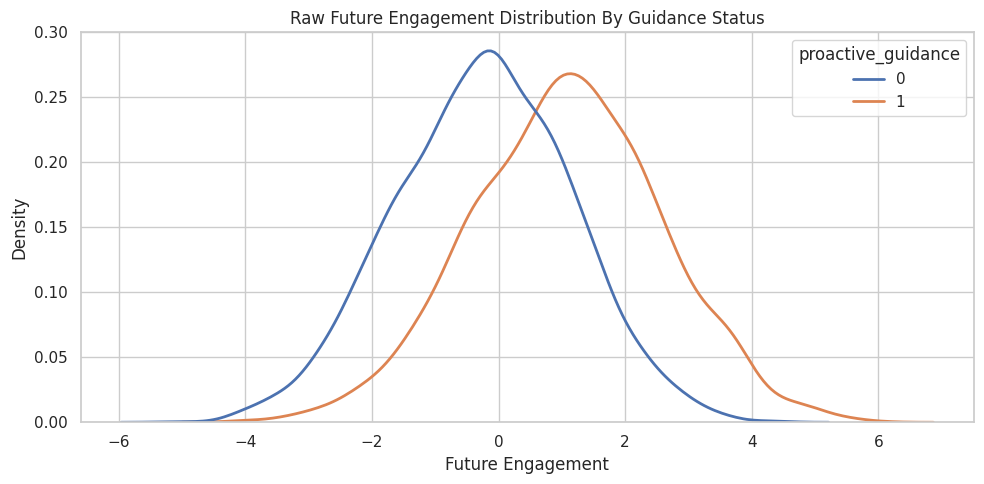

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=analyst_df,
    x="future_engagement",
    hue="proactive_guidance",
    common_norm=False,
    linewidth=2,
    ax=ax,
)
ax.set_title("Raw Future Engagement Distribution By Guidance Status")
ax.set_xlabel("Future Engagement")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "14_raw_outcome_distribution_by_treatment.png", dpi=160, bbox_inches="tight")
plt.show()


The distributions differ visibly, but this plot alone cannot tell us how much of that gap is causal. The next step is to inspect pre-treatment imbalance.


### Covariate Balance Before Adjustment

For each pre-treatment covariate, we compute treated and control means plus the standardized mean difference. Large standardized differences indicate selection into treatment.


In [6]:
# Define reusable helpers for the Covariate Balance Before Adjustment section.
PRE_TREATMENT_COVARIATES = [
    "baseline_need",
    "prior_engagement",
    "account_tenure_z",
    "friction_score",
    "region_risk",
    "high_need_segment",
]
TREATMENT = "proactive_guidance"
OUTCOME = "future_engagement"
MEDIATOR = "activation_depth"
NEGATIVE_CONTROL_OUTCOME = "pre_period_satisfaction"
def standardized_mean_difference(data, column, treatment_col=TREATMENT, weights=None):
    """
    Idea: Measure covariate imbalance as a treated-control mean difference on a pooled-standard-deviation scale.
    
    Parameters
    ----------
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method.
    column : object
        Column name selected from the DataFrame for this calculation.
    treatment_col : str
        Name of the treatment or intervention column.
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    float
        Covariate-balance statistic on a pooled-standard-deviation scale.
    """
    treated_mask = data[treatment_col] == 1
    control_mask = data[treatment_col] == 0
    x_treated = data.loc[treated_mask, column]
    x_control = data.loc[control_mask, column]
    if weights is None:
        treated_mean = x_treated.mean()
        control_mean = x_control.mean()
        treated_var = x_treated.var(ddof=1)
        control_var = x_control.var(ddof=1)
    else:
        w = pd.Series(weights, index=data.index)
        treated_weights = w.loc[treated_mask]
        control_weights = w.loc[control_mask]
        treated_mean = np.average(x_treated, weights=treated_weights)
        control_mean = np.average(x_control, weights=control_weights)
        treated_var = np.average((x_treated - treated_mean) ** 2, weights=treated_weights)
        control_var = np.average((x_control - control_mean) ** 2, weights=control_weights)
    pooled_sd = np.sqrt((treated_var + control_var) / 2)
    return (treated_mean - control_mean) / pooled_sd if pooled_sd > 0 else 0.0
balance_rows = []
for column in PRE_TREATMENT_COVARIATES:
    balance_rows.append(
        {
            "covariate": column,
            "control_mean": analyst_df.loc[analyst_df[TREATMENT] == 0, column].mean(),
            "treated_mean": analyst_df.loc[analyst_df[TREATMENT] == 1, column].mean(),
            "standardized_mean_difference": standardized_mean_difference(analyst_df, column),
        }
    )
raw_balance = pd.DataFrame(balance_rows).sort_values("standardized_mean_difference", key=lambda s: s.abs(), ascending=False)
raw_balance.to_csv(TABLE_DIR / "14_raw_covariate_balance.csv", index=False)
display(raw_balance)


,covariate,control_mean,treated_mean,standardized_mean_difference
0,baseline_need,-0.2872,0.3108,0.6229
3,friction_score,-0.2436,0.2424,0.5010
5,high_need_segment,0.3937,0.6293,0.4850
1,prior_engagement,-0.2161,0.2238,0.4497
2,account_tenure_z,0.1601,-0.1742,-0.3404
4,region_risk,0.3160,0.3818,0.1385


Several covariates are imbalanced, especially baseline need, prior engagement, friction, and account tenure. This confirms that adjustment is necessary.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


#### Plot Raw Covariate Balance

The dashed reference lines at `+/-0.1` are common rough guides. Values outside that band suggest meaningful imbalance.


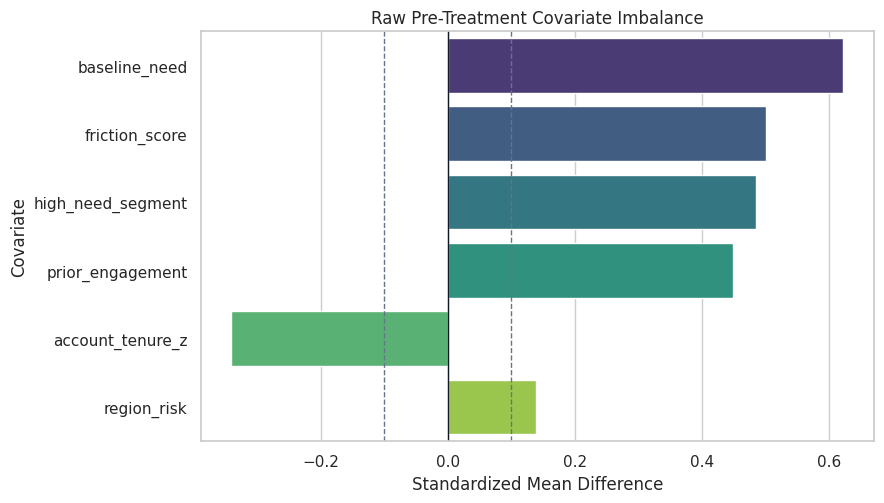

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.2))
sns.barplot(
    data=raw_balance,
    x="standardized_mean_difference",
    y="covariate",
    hue="covariate",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.1, color="#64748b", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="#64748b", linestyle="--", linewidth=1)
ax.set_title("Raw Pre-Treatment Covariate Imbalance")
ax.set_xlabel("Standardized Mean Difference")
ax.set_ylabel("Covariate")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "14_raw_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()


The plot makes the selection problem concrete. We need a graph and adjustment strategy before treating outcome differences as causal.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


### Estimate Propensity Scores for Diagnostics

Even when the final estimator is not propensity weighting, propensity scores are useful diagnostics. They show whether treated and control units have overlapping assignment probabilities.


In [8]:
propensity_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1_000, solver="lbfgs"),
)
X_propensity = analyst_df[PRE_TREATMENT_COVARIATES]
y_treatment = analyst_df[TREATMENT]
propensity_model.fit(X_propensity, y_treatment)
estimated_propensity = propensity_model.predict_proba(X_propensity)[:, 1]
analyst_df = analyst_df.assign(estimated_propensity=estimated_propensity)
propensity_auc = roc_auc_score(y_treatment, estimated_propensity)
propensity_summary = analyst_df["estimated_propensity"].describe().to_frame("estimated_propensity").reset_index()
propensity_summary = propensity_summary.rename(columns={"index": "summary"})
propensity_summary.loc[len(propensity_summary)] = {"summary": "roc_auc", "estimated_propensity": propensity_auc}
propensity_summary.to_csv(TABLE_DIR / "14_propensity_summary.csv", index=False)
print(f"Propensity model ROC AUC: {propensity_auc:.3f}")
display(propensity_summary)


Propensity model ROC AUC: 0.780


,summary,estimated_propensity
0,count,"6,000.0000"
1,mean,0.4788
2,std,0.2414
3,min,0.0063
4,25%,0.2841
5,50%,0.4719
6,75%,0.6728
7,max,0.9843
8,roc_auc,0.7797


The propensity model has meaningful predictive power, which is another sign that treatment was not assigned randomly. The next question is whether there is enough overlap for comparison.


#### Plot Propensity Overlap

Overlap means treated and control units exist at similar propensity levels. Weak overlap makes causal estimates more model-dependent.


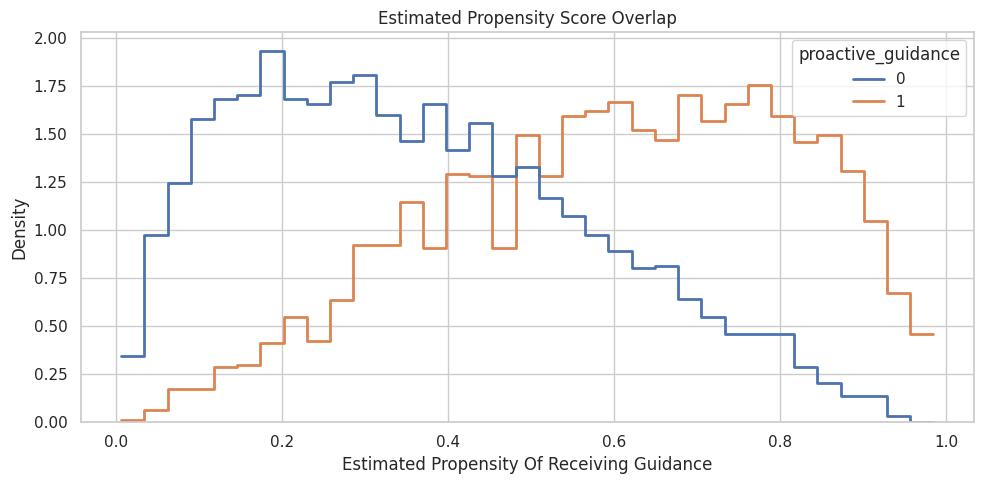

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=analyst_df,
    x="estimated_propensity",
    hue=TREATMENT,
    bins=35,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2,
    ax=ax,
)
ax.set_title("Estimated Propensity Score Overlap")
ax.set_xlabel("Estimated Propensity Of Receiving Guidance")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "14_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


There is usable overlap across much of the propensity range, though the tails are thinner. That means weighting and matching are plausible but still need diagnostics.


### Weight Diagnostics and Weighted Balance

For inverse-propensity weighting, extreme weights can dominate an estimate. We compute stabilized ATE weights, summarize them, and check whether weighting improves covariate balance.


In [10]:
propensity_clip = analyst_df["estimated_propensity"].clip(0.02, 0.98)
treatment_rate = analyst_df[TREATMENT].mean()
stabilized_weight = np.where(
    analyst_df[TREATMENT] == 1,
    treatment_rate / propensity_clip,
    (1 - treatment_rate) / (1 - propensity_clip),
)
analyst_df = analyst_df.assign(stabilized_weight=stabilized_weight)
weight_summary = pd.Series(stabilized_weight, name="stabilized_weight").describe().to_frame().T
weight_summary["effective_sample_size"] = (stabilized_weight.sum() ** 2) / np.sum(stabilized_weight ** 2)
weight_summary.to_csv(TABLE_DIR / "14_weight_summary.csv", index=False)
display(weight_summary)


,count,mean,std,min,25%,50%,75%,max,effective_sample_size
stabilized_weight,"6,000.0000",1.0010,0.7541,0.4886,0.6343,0.7798,1.0766,14.4388,"3,827.9420"


The weights are not wildly extreme, and the effective sample size remains healthy. That supports using propensity weighting as one estimator and one diagnostic lens.


#### Balance Before and After Weighting

A good propensity model should reduce pre-treatment imbalance after weighting. The code below compares raw and weighted standardized mean differences.


In [11]:
weighted_balance_rows = []
for column in PRE_TREATMENT_COVARIATES:
    weighted_balance_rows.append(
        {
            "covariate": column,
            "raw_smd": standardized_mean_difference(analyst_df, column),
            "weighted_smd": standardized_mean_difference(analyst_df, column, weights=analyst_df["stabilized_weight"]),
        }
    )
weighted_balance = pd.DataFrame(weighted_balance_rows)
weighted_balance["absolute_raw_smd"] = weighted_balance["raw_smd"].abs()
weighted_balance["absolute_weighted_smd"] = weighted_balance["weighted_smd"].abs()
weighted_balance = weighted_balance.sort_values("absolute_raw_smd", ascending=False)
weighted_balance.to_csv(TABLE_DIR / "14_weighted_covariate_balance.csv", index=False)
display(weighted_balance)


,covariate,raw_smd,weighted_smd,absolute_raw_smd,absolute_weighted_smd
0,baseline_need,0.6229,0.0177,0.6229,0.0177
3,friction_score,0.5010,-0.0064,0.5010,0.0064
5,high_need_segment,0.4850,0.0067,0.4850,0.0067
1,prior_engagement,0.4497,-0.0140,0.4497,0.0140
2,account_tenure_z,-0.3404,0.0143,0.3404,0.0143
4,region_risk,0.1385,-0.0057,0.1385,0.0057


Weighting substantially reduces the largest imbalances. The result supports observed balance, while unmeasured confounding remains a separate design risk.


#### Plot Balance Improvement

The paired plot below shows each covariate before and after weighting. The goal is to move points closer to zero.


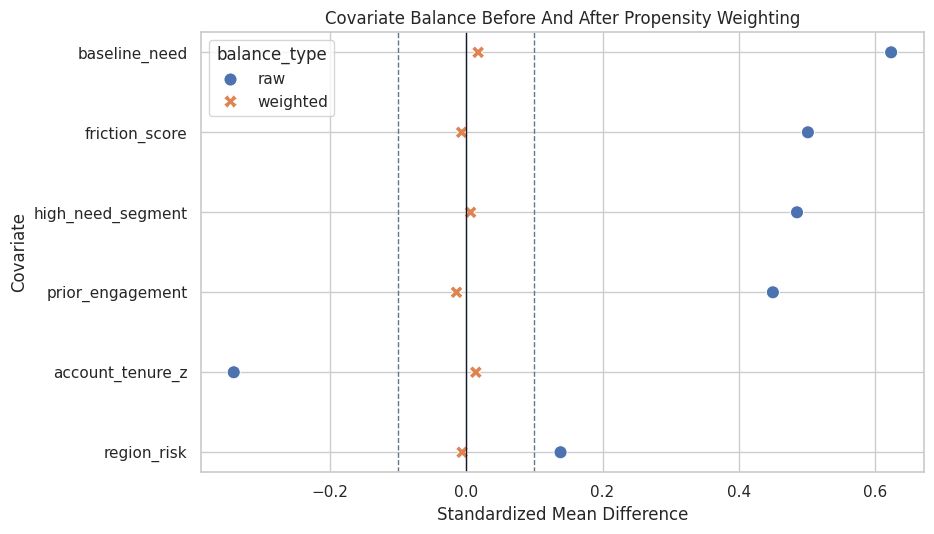

In [12]:
# Build and label the diagnostic visualization for the Plot Balance Improvement section.
balance_plot_df = weighted_balance.melt(
    id_vars="covariate",
    value_vars=["raw_smd", "weighted_smd"],
    var_name="balance_type",
    value_name="smd",
)
balance_plot_df["balance_type"] = balance_plot_df["balance_type"].replace(
    {"raw_smd": "raw", "weighted_smd": "weighted"}
)
fig, ax = plt.subplots(figsize=(9.5, 5.5))
sns.scatterplot(
    data=balance_plot_df,
    x="smd",
    y="covariate",
    hue="balance_type",
    style="balance_type",
    s=90,
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.1, color="#64748b", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="#64748b", linestyle="--", linewidth=1)
ax.set_title("Covariate Balance Before And After Propensity Weighting")
ax.set_xlabel("Standardized Mean Difference")
ax.set_ylabel("Covariate")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "14_balance_before_after_weighting.png", dpi=160, bbox_inches="tight")
plt.show()


The weighted points cluster near zero. This makes the weighted estimator more credible than the raw treated-control contrast, at least for observed covariates.

For causal interpretation, this support check shows when weak overlap may force an estimator to extrapolate beyond comparable treated and control units.
<!-- result-implication-expanded -->




### Specify the Causal Graph

The graph includes pre-treatment confounders, treatment, the post-treatment mediator, and the outcome. The mediator is included in the graph so the timing is explicit, but it is not included in the total-effect adjustment set.


In [13]:
causal_edges = [
    ("baseline_need", "proactive_guidance"),
    ("prior_engagement", "proactive_guidance"),
    ("account_tenure_z", "proactive_guidance"),
    ("friction_score", "proactive_guidance"),
    ("region_risk", "proactive_guidance"),
    ("high_need_segment", "proactive_guidance"),
    ("baseline_need", "activation_depth"),
    ("prior_engagement", "activation_depth"),
    ("friction_score", "activation_depth"),
    ("region_risk", "activation_depth"),
    ("proactive_guidance", "activation_depth"),
    ("baseline_need", "future_engagement"),
    ("prior_engagement", "future_engagement"),
    ("account_tenure_z", "future_engagement"),
    ("friction_score", "future_engagement"),
    ("region_risk", "future_engagement"),
    ("high_need_segment", "future_engagement"),
    ("proactive_guidance", "future_engagement"),
    ("activation_depth", "future_engagement"),
]
causal_graph = nx.DiGraph(causal_edges)
edge_table = pd.DataFrame(causal_edges, columns=["cause", "effect"])
edge_table.to_csv(TABLE_DIR / "14_causal_graph_edges.csv", index=False)
display(edge_table)


,cause,effect
0,baseline_need,proactive_guidance
1,prior_engagement,proactive_guidance
2,account_tenure_z,proactive_guidance
3,friction_score,proactive_guidance
4,region_risk,proactive_guidance
5,high_need_segment,proactive_guidance
6,baseline_need,activation_depth
7,prior_engagement,activation_depth
8,friction_score,activation_depth
9,region_risk,activation_depth


The graph states the total-effect logic: guidance can affect future engagement directly and indirectly through activation depth. Pre-treatment variables can affect treatment and outcome, so they need adjustment.


#### Visualize the DAG

The diagram puts pre-treatment covariates on the left, treatment and mediator in the middle, and the outcome on the right. This visual structure helps prevent bad-control mistakes.


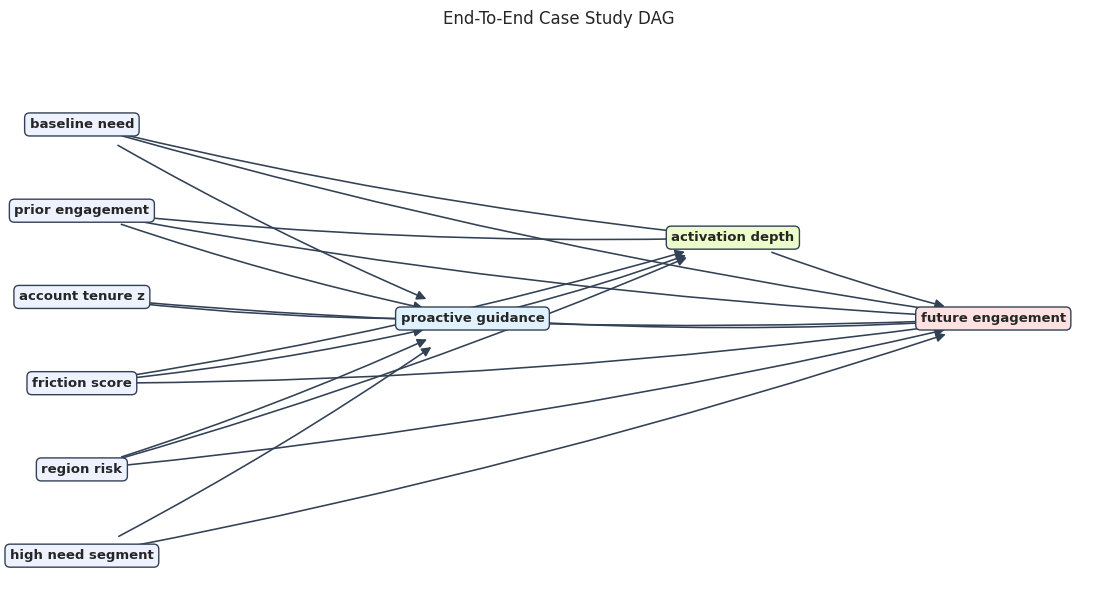

In [14]:
# Build and label the diagnostic visualization for the Visualize The DAG section.
positions = {
    "baseline_need": (0.06, 0.86),
    "prior_engagement": (0.06, 0.70),
    "account_tenure_z": (0.06, 0.54),
    "friction_score": (0.06, 0.38),
    "region_risk": (0.06, 0.22),
    "high_need_segment": (0.06, 0.06),
    "proactive_guidance": (0.42, 0.50),
    "activation_depth": (0.66, 0.65),
    "future_engagement": (0.90, 0.50),
}
node_colors = {
    "baseline_need": "#eef2ff",
    "prior_engagement": "#eef2ff",
    "account_tenure_z": "#eef2ff",
    "friction_score": "#eef2ff",
    "region_risk": "#eef2ff",
    "high_need_segment": "#eef2ff",
    "proactive_guidance": "#e0f2fe",
    "activation_depth": "#ecfccb",
    "future_engagement": "#fee2e2",
}
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_axis_off()
for source, target in causal_edges:
    ax.annotate(
        "",
        xy=positions[target],
        xytext=positions[source],
        arrowprops=dict(
            arrowstyle="-|>",
            color="#334155",
            linewidth=1.15,
            shrinkA=30,
            shrinkB=36,
            mutation_scale=14,
            connectionstyle="arc3,rad=0.035",
        ),
    )
for node, (x, y) in positions.items():
    ax.text(
        x,
        y,
        node.replace("_", " "),
        ha="center",
        va="center",
        fontsize=9.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.38",
            facecolor=node_colors[node],
            edgecolor="#334155",
            linewidth=1.0,
        ),
    )
ax.set_title("End-To-End Case Study DAG", pad=18)
fig.savefig(FIGURE_DIR / "14_case_study_dag.png", dpi=160, bbox_inches="tight")
plt.show()


The DAG makes the mediator visible without turning it into a control variable for the total effect. That is exactly why drawing the graph is useful.


#### Build the DoWhy Model

Now we pass the graph, treatment, outcome, and analyst-facing data into DoWhy. The hidden truth columns are excluded.


In [15]:
# Fit or evaluate the model objects used in the Build The DoWhy Model section.
graph_dot = """
digraph {
    baseline_need -> proactive_guidance;
    prior_engagement -> proactive_guidance;
    account_tenure_z -> proactive_guidance;
    friction_score -> proactive_guidance;
    region_risk -> proactive_guidance;
    high_need_segment -> proactive_guidance;
    baseline_need -> activation_depth;
    prior_engagement -> activation_depth;
    friction_score -> activation_depth;
    region_risk -> activation_depth;
    proactive_guidance -> activation_depth;
    baseline_need -> future_engagement;
    prior_engagement -> future_engagement;
    account_tenure_z -> future_engagement;
    friction_score -> future_engagement;
    region_risk -> future_engagement;
    high_need_segment -> future_engagement;
    proactive_guidance -> future_engagement;
    activation_depth -> future_engagement;
}
"""
dowhy_df = analyst_df.drop(columns=["estimated_propensity", "stabilized_weight"]).copy()
case_model = CausalModel(
    data=dowhy_df,
    treatment=TREATMENT,
    outcome=OUTCOME,
    graph=graph_dot,
)
print("CausalModel created for proactive guidance -> future engagement.")


CausalModel created for proactive guidance -> future engagement.


The model now knows the graph and variable roles. The next step is identification: finding a valid adjustment formula under the graph assumptions.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


### Identify the Total Effect

DoWhy identifies the estimand implied by the graph. For this total-effect question, the valid backdoor adjustment set should include pre-treatment covariates and exclude activation depth.


In [16]:
identified_estimand = case_model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                                    ↪
─────────────────────(E[future_engagement|prior_engagement,account_tenure_z,hi ↪
d[proactive_guidance]                                                          ↪

↪                                                           
↪ gh_need_segment,friction_score,baseline_need,region_risk])
↪                                                           
Estimand assumption 1, Unconfoundedness: If U→{proactive_guidance} and U→future_engagement then P(future_engagement|proactive_guidance,prior_engagement,account_tenure_z,high_need_segment,friction_score,baseline_need,region_risk,U) = P(future_engagement|proactive_guidance,prior_engagement,account_tenure_z,high_need_segment,friction_score,baseline_need,region_risk)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: fr

The printed backdoor estimand lists pre-treatment variables as adjustment variables. Activation depth does not appear in the adjustment set because it is downstream of treatment.


#### Manual Baseline Estimates

Before using DoWhy estimators, compute three simple manual comparisons: raw difference, adjusted regression, and stabilized IPW. This makes the DoWhy estimates easier to audit.


In [17]:
# Raw treated-control difference.
manual_raw_difference = raw_difference
# Adjusted regression for the total effect: do not include the mediator.
adjusted_design = sm.add_constant(analyst_df[[TREATMENT] + PRE_TREATMENT_COVARIATES])
adjusted_regression = sm.OLS(analyst_df[OUTCOME], adjusted_design).fit()
manual_adjusted_regression = adjusted_regression.params[TREATMENT]
# Stabilized IPW estimate.
treated_weighted_mean = np.average(
    analyst_df.loc[analyst_df[TREATMENT] == 1, OUTCOME],
    weights=analyst_df.loc[analyst_df[TREATMENT] == 1, "stabilized_weight"],
)
control_weighted_mean = np.average(
    analyst_df.loc[analyst_df[TREATMENT] == 0, OUTCOME],
    weights=analyst_df.loc[analyst_df[TREATMENT] == 0, "stabilized_weight"],
)
manual_ipw = treated_weighted_mean - control_weighted_mean
manual_estimates = pd.DataFrame(
    [
        {"estimator": "raw difference", "estimate": manual_raw_difference, "notes": "confounded association"},
        {"estimator": "adjusted OLS", "estimate": manual_adjusted_regression, "notes": "adjusts for pre-treatment covariates"},
        {"estimator": "stabilized IPW", "estimate": manual_ipw, "notes": "weights by estimated propensity"},
    ]
)
manual_estimates["known_true_ate"] = true_ate
manual_estimates["absolute_error"] = (manual_estimates["estimate"] - true_ate).abs()
manual_estimates.to_csv(TABLE_DIR / "14_manual_estimates.csv", index=False)
display(manual_estimates)


,estimator,estimate,notes,known_true_ate,absolute_error
0,raw difference,1.3247,confounded association,0.8496,0.4751
1,adjusted OLS,0.8352,adjusts for pre-treatment covariates,0.8496,0.0144
2,stabilized IPW,0.8467,weights by estimated propensity,0.8496,0.0029


The adjusted and weighted estimates move closer to the known effect than the raw difference. That is the pattern we want in this worked case.




#### DoWhy Estimator Comparison

Now we estimate the same identified estimand with several DoWhy estimators. Agreement across reasonable estimators supports stability across methods and improves confidence that the result is not tied to one estimator.


In [18]:
dowhy_estimator_specs = [
    ("linear_regression", "backdoor.linear_regression"),
    ("propensity_score_matching", "backdoor.propensity_score_matching"),
    ("propensity_score_stratification", "backdoor.propensity_score_stratification"),
    ("propensity_score_weighting", "backdoor.propensity_score_weighting"),
]
dowhy_estimate_rows = []
dowhy_estimate_objects = {}
for estimator_label, method_name in dowhy_estimator_specs:
    estimate = case_model.estimate_effect(
        identified_estimand,
        method_name=method_name,
        control_value=0,
        treatment_value=1,
    )
    dowhy_estimate_objects[estimator_label] = estimate
    dowhy_estimate_rows.append(
        {
            "estimator": estimator_label,
            "method_name": method_name,
            "estimate": estimate.value,
            "known_true_ate": true_ate,
            "absolute_error": abs(estimate.value - true_ate),
        }
    )
dowhy_estimates = pd.DataFrame(dowhy_estimate_rows).sort_values("absolute_error")
dowhy_estimates.to_csv(TABLE_DIR / "14_dowhy_estimator_comparison.csv", index=False)
display(dowhy_estimates)


,estimator,method_name,estimate,known_true_ate,absolute_error
3,propensity_score_weighting,backdoor.propensity_score_weighting,0.8540,0.8496,0.0044
2,propensity_score_stratification,backdoor.propensity_score_stratification,0.8368,0.8496,0.0128
0,linear_regression,backdoor.linear_regression,0.8352,0.8496,0.0144
1,propensity_score_matching,backdoor.propensity_score_matching,0.8893,0.8496,0.0398


The DoWhy estimates cluster near the known true effect. In real data, the known truth is unavailable, so the clustering itself would be one part of the credibility story.


#### Plot Estimator Comparison

The plot compares raw, manual adjusted, and DoWhy estimates against the known truth. The truth line is available only because this is a teaching simulation.


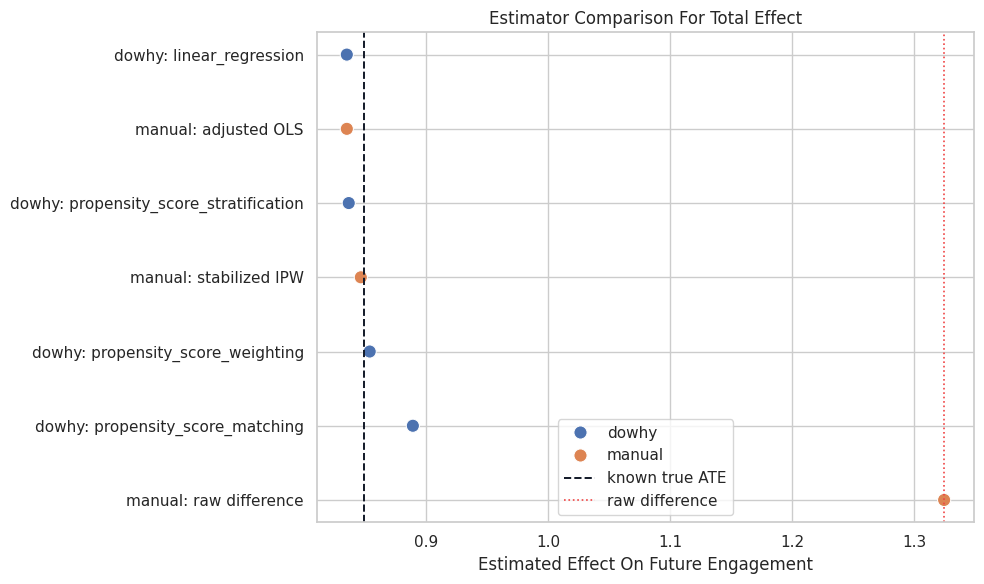

In [19]:
# Build and label the diagnostic visualization for the Plot Estimator Comparison section.
plot_estimates = pd.concat(
    [
        manual_estimates.assign(source="manual")[["source", "estimator", "estimate"]],
        dowhy_estimates.assign(source="dowhy")[["source", "estimator", "estimate"]],
    ],
    ignore_index=True,
)
plot_estimates["label"] = plot_estimates["source"] + ": " + plot_estimates["estimator"]
plot_estimates = plot_estimates.sort_values("estimate")
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=plot_estimates,
    x="estimate",
    y="label",
    hue="source",
    s=90,
    ax=ax,
)
ax.axvline(true_ate, color="#111827", linestyle="--", linewidth=1.4, label="known true ATE")
ax.axvline(manual_raw_difference, color="#ef4444", linestyle=":", linewidth=1.2, label="raw difference")
ax.set_title("Estimator Comparison For Total Effect")
ax.set_xlabel("Estimated Effect On Future Engagement")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "14_estimator_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The adjusted estimates are much closer to the known effect than the raw difference. That is a clean demonstration of why the causal graph and adjustment set matter.




#### Bad-Control Demonstration

Activation depth is post-treatment. If we include it in a total-effect regression, we block the mediated pathway and estimate something closer to a direct effect. The code below shows the size of that mistake.


In [20]:
bad_control_design = sm.add_constant(analyst_df[[TREATMENT, MEDIATOR] + PRE_TREATMENT_COVARIATES])
bad_control_regression = sm.OLS(analyst_df[OUTCOME], bad_control_design).fit()
bad_control_comparison = pd.DataFrame(
    [
        {
            "model": "raw outcome ~ treatment",
            "treatment_coefficient": manual_raw_difference,
            "estimand reading": "confounded association",
        },
        {
            "model": "outcome ~ treatment + pre-treatment covariates",
            "treatment_coefficient": manual_adjusted_regression,
            "estimand reading": "adjusted total effect",
        },
        {
            "model": "outcome ~ treatment + activation depth + pre-treatment covariates",
            "treatment_coefficient": bad_control_regression.params[TREATMENT],
            "estimand reading": "direct-effect-like coefficient after blocking mediator path",
        },
    ]
)
bad_control_comparison.to_csv(TABLE_DIR / "14_bad_control_comparison.csv", index=False)
display(bad_control_comparison)


,model,treatment_coefficient,estimand reading
0,raw outcome ~ treatment,1.3247,confounded association
1,outcome ~ treatment + pre-treatment covariates,0.8352,adjusted total effect
2,outcome ~ treatment + activation depth + pre-treatment covariates,0.4849,direct-effect-like coefficient after blocking mediator path


The mediator-adjusted coefficient is smaller because part of the treatment effect flows through activation depth. That is not a bug; it is a different estimand.


#### Plot the Bad-Control Effect

This chart emphasizes how much the treatment coefficient changes when a post-treatment mediator is added as a control.


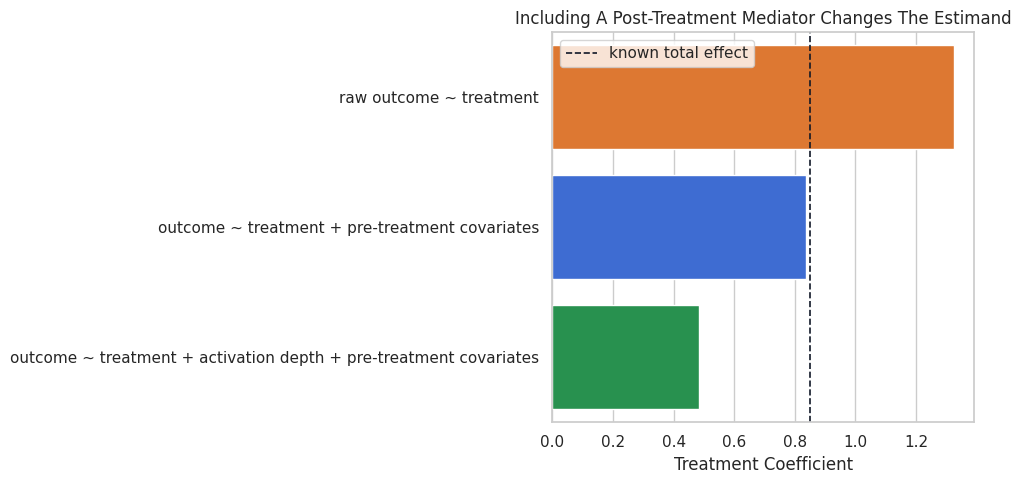

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=bad_control_comparison,
    x="treatment_coefficient",
    y="model",
    hue="model",
    dodge=False,
    palette=["#f97316", "#2563eb", "#16a34a"],
    legend=False,
    ax=ax,
)
ax.axvline(true_ate, color="#111827", linestyle="--", linewidth=1.2, label="known total effect")
ax.set_title("Including A Post-Treatment Mediator Changes The Estimand")
ax.set_xlabel("Treatment Coefficient")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "14_bad_control_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The bad-control model would understate the total effect. This is a common applied mistake, and the DAG is the best defense against it.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


#### Segment Heterogeneity

The average effect is useful, but the simulated treatment effect is larger for high-need units. We inspect segment-level effects using the stabilized weights and compare them to the known segment truth.


In [22]:
segment_rows = []
for segment_value, segment_name in [(0, "lower baseline need"), (1, "higher baseline need")]:
    segment_df = analyst_df[analyst_df["high_need_segment"] == segment_value]
    segment_truth = raw_case_df.loc[segment_df.index, "true_total_effect"].mean()
    treated_mean = np.average(
        segment_df.loc[segment_df[TREATMENT] == 1, OUTCOME],
        weights=segment_df.loc[segment_df[TREATMENT] == 1, "stabilized_weight"],
    )
    control_mean = np.average(
        segment_df.loc[segment_df[TREATMENT] == 0, OUTCOME],
        weights=segment_df.loc[segment_df[TREATMENT] == 0, "stabilized_weight"],
    )
    segment_rows.append(
        {
            "segment": segment_name,
            "rows": len(segment_df),
            "weighted_effect_estimate": treated_mean - control_mean,
            "known_segment_ate": segment_truth,
            "treatment_rate": segment_df[TREATMENT].mean(),
        }
    )
segment_effects = pd.DataFrame(segment_rows)
segment_effects["absolute_error"] = (segment_effects["weighted_effect_estimate"] - segment_effects["known_segment_ate"]).abs()
segment_effects.to_csv(TABLE_DIR / "14_segment_effects.csv", index=False)
display(segment_effects)


,segment,rows,weighted_effect_estimate,known_segment_ate,treatment_rate,absolute_error
0,lower baseline need,2961,0.8078,0.7371,0.3597,0.0707
1,higher baseline need,3039,0.8752,0.9592,0.5949,0.0840


The high-need segment has the larger effect, which matches the simulated truth. In real observational data, this kind of subgroup result should be treated as exploratory unless pre-specified or validated.


#### Plot Segment Effects

The plot compares the segment estimates to their known teaching truth. The gap between segments is often more decision-relevant than the overall average.


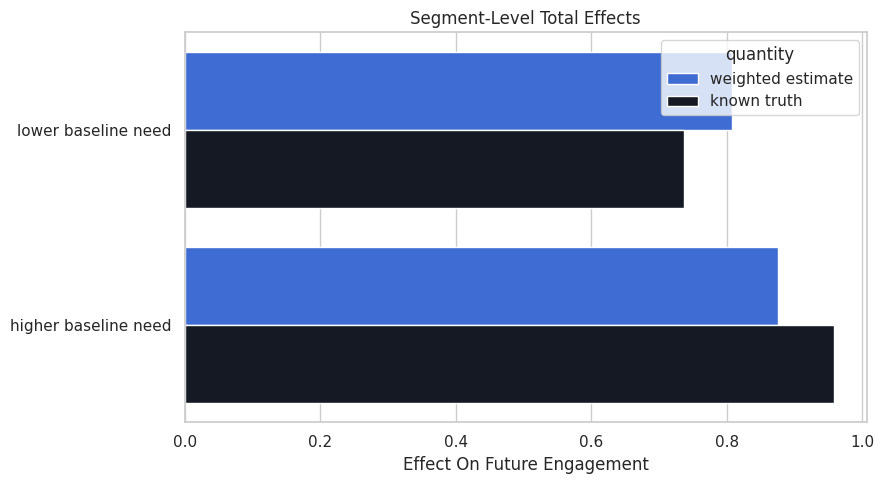

In [23]:
segment_plot_df = segment_effects.melt(
    id_vars="segment",
    value_vars=["weighted_effect_estimate", "known_segment_ate"],
    var_name="quantity",
    value_name="effect",
)
segment_plot_df["quantity"] = segment_plot_df["quantity"].replace(
    {"weighted_effect_estimate": "weighted estimate", "known_segment_ate": "known truth"}
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=segment_plot_df,
    x="effect",
    y="segment",
    hue="quantity",
    palette=["#2563eb", "#111827"],
    ax=ax,
)
ax.set_title("Segment-Level Total Effects")
ax.set_xlabel("Effect On Future Engagement")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "14_segment_effects.png", dpi=160, bbox_inches="tight")
plt.show()


The segment pattern suggests guidance is more valuable for higher-need units. That is a targeting hypothesis, not a deployment decision by itself.

The decision implication is that estimated gains need to be filtered through uncertainty, cost, support, and operational constraints before becoming actions.
<!-- result-implication-expanded -->


#### Negative-Control Outcome Check

A negative-control outcome is something the treatment should not causally affect. Here `pre_period_satisfaction` is measured before treatment, so guidance cannot cause it. If an adjusted model still finds a large treatment effect on this pre-period outcome, that would suggest residual confounding.


In [24]:
# Fit or evaluate the model objects used in the Negative-Control Outcome Check section.
negative_control_naive = sm.OLS(
    analyst_df[NEGATIVE_CONTROL_OUTCOME],
    sm.add_constant(analyst_df[[TREATMENT]]),
).fit()
negative_control_adjusted = sm.OLS(
    analyst_df[NEGATIVE_CONTROL_OUTCOME],
    sm.add_constant(analyst_df[[TREATMENT] + PRE_TREATMENT_COVARIATES]),
).fit()
negative_control_table = pd.DataFrame(
    [
        {
            "model": "negative control: naive",
            "treatment_coefficient": negative_control_naive.params[TREATMENT],
            "standard_error": negative_control_naive.bse[TREATMENT],
            "reading": "raw association before adjustment",
        },
        {
            "model": "negative control: adjusted",
            "treatment_coefficient": negative_control_adjusted.params[TREATMENT],
            "standard_error": negative_control_adjusted.bse[TREATMENT],
            "reading": "should be close to zero if observed confounding is handled",
        },
    ]
)
negative_control_table.to_csv(TABLE_DIR / "14_negative_control_outcome.csv", index=False)
display(negative_control_table)


,model,treatment_coefficient,standard_error,reading
0,negative control: naive,0.4673,0.0235,raw association before adjustment
1,negative control: adjusted,0.0227,0.0235,should be close to zero if observed confounding is handled


The adjusted negative-control coefficient is much closer to zero than the naive coefficient. This supports, but does not prove, the observed adjustment strategy.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->




#### Run DoWhy Refuters

Refuters check whether the estimate behaves sensibly under deliberate perturbations. We use the linear regression estimate as the baseline because it is fast, transparent, and close to the known truth in this simulation.


In [25]:
# Prepare intermediate objects for the Run DoWhy Refuters section.
baseline_dowhy_estimate = dowhy_estimate_objects["linear_regression"]
random_common_cause_refutation = case_model.refute_estimate(
    identified_estimand,
    baseline_dowhy_estimate,
    method_name="random_common_cause",
    num_simulations=10,
    random_state=np.random.RandomState(1401),
    n_jobs=1,
)
placebo_treatment_refutation = case_model.refute_estimate(
    identified_estimand,
    baseline_dowhy_estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    num_simulations=10,
    random_state=np.random.RandomState(1402),
    n_jobs=1,
)
data_subset_refutation = case_model.refute_estimate(
    identified_estimand,
    baseline_dowhy_estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.80,
    num_simulations=10,
    random_state=np.random.RandomState(1403),
    n_jobs=1,
)
print(random_common_cause_refutation)
print(placebo_treatment_refutation)
print(data_subset_refutation)


Refute: Add a random common cause
Estimated effect:0.8352181563708893
New effect:0.8352136116020732
p value:0.4754479082077938

Refute: Use a Placebo Treatment
Estimated effect:0.8352181563708893
New effect:0.009719829616254783
p value:0.3728059681347816

Refute: Use a subset of data
Estimated effect:0.8352181563708893
New effect:0.8292451720091082
p value:0.21892525767679105



A stable estimate should not move much when a random covariate is added. A placebo treatment should produce an effect near zero. A subset refuter should produce a similar estimate on repeated subsets.


### Summarize Refuter Results

The raw refuter printouts are useful but verbose. This table extracts the main quantities for reporting.


In [26]:
refutation_summary = pd.DataFrame(
    [
        {
            "check": "random common cause",
            "original_effect": baseline_dowhy_estimate.value,
            "new_effect": random_common_cause_refutation.new_effect,
            "desired_behavior": "close to original estimate",
        },
        {
            "check": "placebo treatment",
            "original_effect": baseline_dowhy_estimate.value,
            "new_effect": placebo_treatment_refutation.new_effect,
            "desired_behavior": "near zero",
        },
        {
            "check": "data subset",
            "original_effect": baseline_dowhy_estimate.value,
            "new_effect": data_subset_refutation.new_effect,
            "desired_behavior": "close to original estimate",
        },
    ]
)
refutation_summary["absolute_change_from_original"] = (
    refutation_summary["new_effect"] - refutation_summary["original_effect"]
).abs()
refutation_summary.to_csv(TABLE_DIR / "14_refutation_summary.csv", index=False)
display(refutation_summary)


,check,original_effect,new_effect,desired_behavior,absolute_change_from_original
0,random common cause,0.8352,0.8352,close to original estimate,0.0000
1,placebo treatment,0.8352,0.0097,near zero,0.8255
2,data subset,0.8352,0.8292,close to original estimate,0.0060


The placebo check is the most important falsification check here: a fake treatment should not reproduce the original effect. The random-cause and subset checks assess stability.


#### Plot Refuter Results

The plot compares each refuter's new effect to the original baseline estimate and to zero.


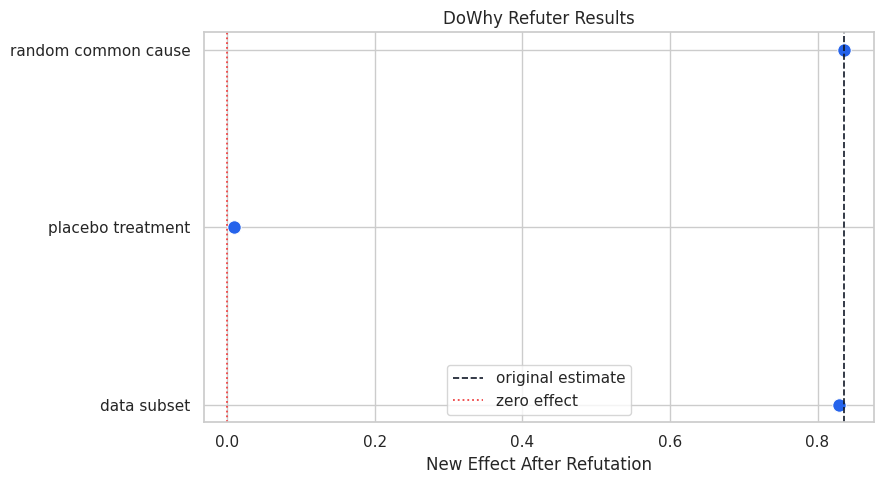

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=refutation_summary,
    x="new_effect",
    y="check",
    s=95,
    color="#2563eb",
    ax=ax,
)
ax.axvline(baseline_dowhy_estimate.value, color="#111827", linestyle="--", linewidth=1.2, label="original estimate")
ax.axvline(0, color="#ef4444", linestyle=":", linewidth=1.3, label="zero effect")
ax.set_title("DoWhy Refuter Results")
ax.set_xlabel("New Effect After Refutation")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "14_refuter_results.png", dpi=160, bbox_inches="tight")
plt.show()


The refuter results behave as expected in this controlled case. That raises confidence in the workflow, while still leaving the usual observational caveats in place.


#### Hidden-Confounding Sensitivity

The main untestable assumption is no unmeasured confounding. DoWhy's unobserved-common-cause refuter simulates how the estimate could move under hypothetical hidden confounders of different strengths.


In [28]:
treatment_strength_grid = np.array([0.01, 0.03, 0.05])
outcome_strength_grid = np.array([0.05, 0.15, 0.30])
hidden_confounder_refutation = case_model.refute_estimate(
    identified_estimand,
    baseline_dowhy_estimate,
    method_name="add_unobserved_common_cause",
    simulation_method="direct-simulation",
    confounders_effect_on_treatment="binary_flip",
    confounders_effect_on_outcome="linear",
    effect_strength_on_treatment=treatment_strength_grid,
    effect_strength_on_outcome=outcome_strength_grid,
    plotmethod=None,
)
hidden_confounding_matrix = pd.DataFrame(
    hidden_confounder_refutation.new_effect_array,
    index=[f"treatment strength {value:.2f}" for value in treatment_strength_grid],
    columns=[f"outcome strength {value:.2f}" for value in outcome_strength_grid],
)
hidden_confounding_matrix.to_csv(TABLE_DIR / "14_hidden_confounding_sensitivity_matrix.csv")
display(hidden_confounding_matrix)
print(f"Original estimate: {baseline_dowhy_estimate.value:.3f}")
print(f"Range after simulated hidden confounding: {hidden_confounder_refutation.new_effect}")


,outcome strength 0.05,outcome strength 0.15,outcome strength 0.30
treatment strength 0.01,0.8086,0.7814,0.7678
treatment strength 0.03,0.6872,0.6319,0.5885
treatment strength 0.05,0.4978,0.4628,0.3726


Original estimate: 0.835
Range after simulated hidden confounding: (np.float64(0.3725543493325587), np.float64(0.8086438421813065))


The sensitivity table shows that stronger hidden confounding can reduce the estimate. This finding does not mean such confounding exists. It clarifies what kind of unobserved bias would threaten the conclusion.


#### Final Evidence Scorecard

A useful causal report combines estimates with diagnostics. The scorecard below summarizes the main evidence in plain language.


In [29]:
main_dowhy_estimate = baseline_dowhy_estimate.value
best_propensity_estimate = dowhy_estimates.loc[dowhy_estimates["estimator"] == "propensity_score_weighting", "estimate"].iloc[0]
placebo_effect = placebo_treatment_refutation.new_effect
adjusted_negative_control = negative_control_table.loc[
    negative_control_table["model"] == "negative control: adjusted",
    "treatment_coefficient",
].iloc[0]
max_weighted_smd = weighted_balance["absolute_weighted_smd"].max()
scorecard = pd.DataFrame(
    [
        {
            "evidence item": "main adjusted DoWhy estimate",
            "result": f"{main_dowhy_estimate:.3f}",
            "reading": "positive estimated total effect after graph-based adjustment",
        },
        {
            "evidence item": "estimator agreement",
            "result": f"weighting estimate {best_propensity_estimate:.3f}",
            "reading": "propensity and regression estimates tell a similar story",
        },
        {
            "evidence item": "overlap and balance",
            "result": f"max weighted SMD {max_weighted_smd:.3f}",
            "reading": "observed covariates are much better balanced after weighting",
        },
        {
            "evidence item": "placebo treatment refuter",
            "result": f"{placebo_effect:.3f}",
            "reading": "fake treatment does not reproduce the main effect",
        },
        {
            "evidence item": "negative-control outcome",
            "result": f"adjusted coefficient {adjusted_negative_control:.3f}",
            "reading": "pre-period outcome association mostly disappears after adjustment",
        },
        {
            "evidence item": "hidden-confounding sensitivity",
            "result": f"range {hidden_confounder_refutation.new_effect[0]:.3f} to {hidden_confounder_refutation.new_effect[1]:.3f}",
            "reading": "strong unobserved confounding could still reduce the estimate",
        },
    ]
)
scorecard.to_csv(TABLE_DIR / "14_evidence_scorecard.csv", index=False)
display(scorecard)


,evidence item,result,reading
0,main adjusted DoWhy estimate,0.835,positive estimated total effect after graph-based adjustment
1,estimator agreement,weighting estimate 0.854,propensity and regression estimates tell a similar story
2,overlap and balance,max weighted SMD 0.018,observed covariates are much better balanced after weighting
3,placebo treatment refuter,0.010,fake treatment does not reproduce the main effect
4,negative-control outcome,adjusted coefficient 0.023,pre-period outcome association mostly disappears after adjustment
5,hidden-confounding sensitivity,range 0.373 to 0.809,strong unobserved confounding could still reduce the estimate


The scorecard supports a positive effect but keeps the observational limitation visible. This is the tone an end-to-end causal report should aim for.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->


### Reporting and Takeaways

A finished analysis should be easy for another careful reader to review. It should state the causal question, target estimand, identification assumptions, main estimate, diagnostics, sensitivity checks, and remaining limitations in plain language. The goal is a clear analytical conclusion supported by the tables and figures already shown in the lesson.


In [30]:
final_summary = pd.DataFrame(
    [
        {
            "section": "Causal question",
            "summary": "Estimate the average total effect of proactive guidance on future engagement.",
        },
        {
            "section": "Primary estimate",
            "summary": f"The main DoWhy adjusted estimate is {main_dowhy_estimate:.3f}; the known teaching ATE is {true_ate:.3f}.",
        },
        {
            "section": "Estimator robustness",
            "summary": "Regression, matching, stratification, and weighting estimates are directionally consistent.",
        },
        {
            "section": "Diagnostics",
            "summary": "Observed covariate imbalance is substantial before adjustment and much smaller after weighting.",
        },
        {
            "section": "Falsification checks",
            "summary": "Placebo and negative-control checks behave as expected in the example data.",
        },
        {
            "section": "Important caveat",
            "summary": "The result still depends on the no-unmeasured-confounding assumption.",
        },
        {
            "section": "Recommended next step",
            "summary": "Use this analysis to justify a prospective experiment or a more controlled rollout design.",
        },
    ]
)
final_summary.to_csv(TABLE_DIR / "14_final_case_study_summary.csv", index=False)
display(final_summary)


,section,summary
0,Causal question,Estimate the average total effect of proactive guidance on future engagement.
1,Primary estimate,The main DoWhy adjusted estimate is 0.835; the known teaching ATE is 0.850.
2,Estimator robustness,"Regression, matching, stratification, and weighting estimates are directionally consistent."
3,Diagnostics,Observed covariate imbalance is substantial before adjustment and much smaller after weighting.
4,Falsification checks,Placebo and negative-control checks behave as expected in the example data.
5,Important caveat,The result still depends on the no-unmeasured-confounding assumption.
6,Recommended next step,Use this analysis to justify a prospective experiment or a more controlled rollout design.


This summary is measured. Observational analysis can guide decisions and experiment design, but it should not be reported as if treatment were randomized.


### Final Checklist

The last checklist can be reused in other applied DoWhy analyses. It is a compact version of the workflow from this lesson.


| check | status in this lesson |
| --- | --- |
| Question defined before modeling | done |
| Variable timing documented | done |
| Pre-treatment confounding inspected | done |
| Overlap and balance checked | done |
| DAG drawn and encoded | done |
| DoWhy estimand identified | done |
| Multiple estimators compared | done |
| Post-treatment bad control avoided | done |
| Refuters and negative controls run | done |
| Limitations reported with estimate | done |


The checklist is the main reusable output from this capstone. The exact estimator may change across applications, but the structure of disciplined causal analysis should remain stable.


## Closing Notes

This end-to-end case study pulled together the major ideas from the earlier DoWhy tutorials:

- graph-based adjustment;
- propensity overlap and balance;
- regression and propensity estimators;
- bad-control reasoning;
- heterogeneous effects;
- refuters and negative controls;
- hidden-confounding sensitivity;
- report-style summarization.

The sequence closes with common pitfalls, debugging patterns, and reporting habits that make causal analyses easier to trust.
